# Project: Neural Estate

**Teamleden:**  
- Ids Grunstra
- Chris de Nooijer
- Tom Spoler
- Haben Sebhatu

# 1. Opdracht 1: Exploratieve Data Analyse (EDA)

## 1.2 Setup: Libraries importeren

In [1]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam  # pyright: ignore[reportMissingImports]
from tensorflow.keras.callbacks import EarlyStopping  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
# Importeer TensorFlow en Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential  # pyright: ignore[reportMissingImports]
from tensorflow.keras.layers import Dense  # pyright: ignore[reportMissingImports]


## 1.3 Setup: Configuratie en paden

Hieronder stellen we de paden in naar de data en definieren we eenvoudige hulpfuncties voor de exploratieve data-analyse.

In [27]:
# Configuratie: paden naar de datamap
data_dir = "."
train_img_dir = os.path.join(data_dir, "Train")
train_img_dir

'./Train'

## 1.4 Beelddata: Afbeeldingen inlezen en tonen

### 1.4.1 Structuur van de afbeeldingen


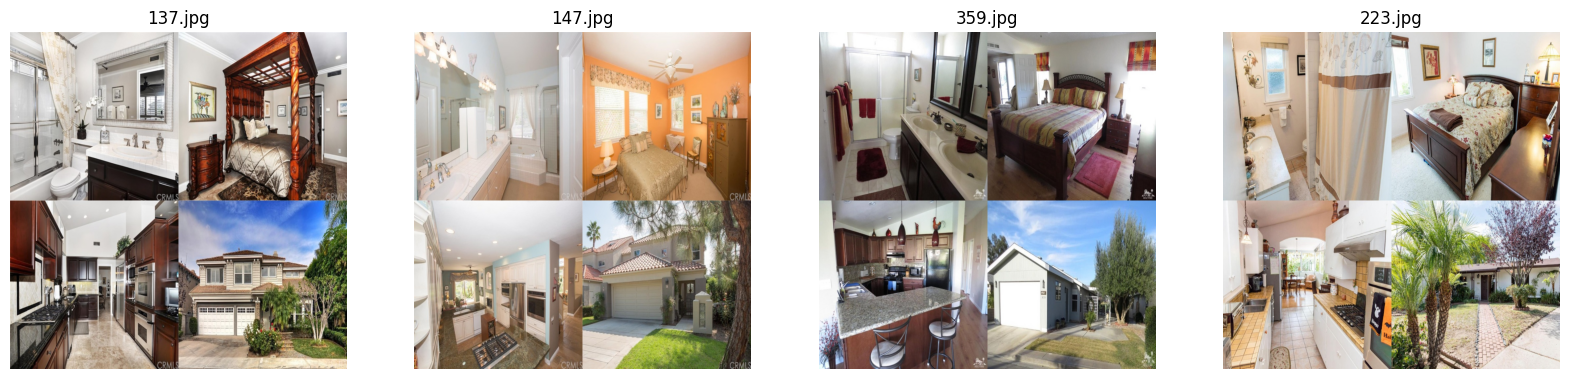

In [3]:
# Lees alle bestanden uit de map Train en kies er 4 willekeurig
train_img_dir = "Train"
image_files = os.listdir(train_img_dir)
sample = random.sample(image_files, 4)

# Maak een plot aan met 4 vakjes naast elkaar
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Loop door de 4 gekozen foto's en laat ze zien
for ax, fname in zip(axes, sample):
    img_path = train_img_dir + "/" + fname
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off") # Verberg de assen

plt.show()

Elke afbeelding in de dataset is een samengevoegde collage van 4 foto's van dezelfde woning, 


| Linksboven      | Rechtsboven     |
|-----------------|-----------------|
| Slaapkamer      | Badkamer        |
| Linksonder  | Rechtsonder |
| Keuken          | Vooraanzicht    |

Dit geeft het model visuele informatie over de staat en stijl van de woning vanuit meerdere perspectieven.

- - -
## 1.5 metadata inladen

Het bestand train.csv bevat de metadata van elke woning, zoals oppervlakte, aantal kamers en de doelvariabele **Price**.

In [4]:
# Laad de tabulaire data en print een samenvatting
csv_path = os.path.join(data_dir, "train.csv")
df = pd.read_csv(csv_path)

print("=== Eerste rijen (head) ===")
display(df.head())

print("\n=== Statistische samenvatting (describe) ===")
display(df.describe())

print("\n=== Info & missing values (info) ===")
df.info()

=== Eerste rijen (head) ===


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226



=== Statistische samenvatting (describe) ===


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,250.500000,3.350000,2.669500,2369.64600,35.128844,-116.469049,5.980218e+05
std,144.481833,1.172283,1.017578,1208.18261,2.386173,6.554434,5.240649e+05
min,1.000000,1.000000,1.000000,701.00000,32.631500,-122.368300,2.200000e+04
25%,125.750000,2.000000,2.000000,1440.00000,33.808200,-119.802500,2.350000e+05
50%,250.500000,3.000000,2.500000,2097.50000,33.920800,-117.609600,5.300000e+05
75%,375.250000,4.000000,3.000000,3104.50000,35.640600,-116.371300,7.490000e+05
max,500.000000,10.000000,7.000000,9583.00000,47.791800,-87.885900,5.858000e+06



=== Info & missing values (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   House ID   500 non-null    int64  
 1   Bedrooms   500 non-null    int64  
 2   Bathrooms  500 non-null    float64
 3   Area       500 non-null    int64  
 4   Latitude   500 non-null    float64
 5   Longitude  500 non-null    float64
 6   Price      500 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 27.5 KB


- - -
## 1.6 Visualisaties

### 1.6.1 Scatterplot: Oppervlakte vs. Prijs

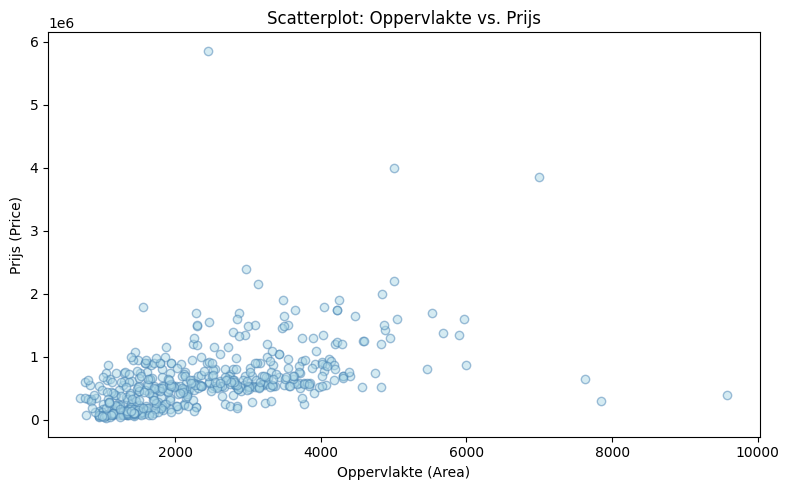

In [5]:
# Scatterplot: Oppervlakte vs. Prijs
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df["Area"],
    df["Price"],
    alpha=0.5,
    edgecolors="steelblue",
    facecolors="lightblue",
)
ax.set_xlabel("Oppervlakte (Area)")
ax.set_ylabel("Prijs (Price)")
ax.set_title("Scatterplot: Oppervlakte vs. Prijs")
plt.tight_layout()
plt.show()

### Bevindingen

Positieve trend: Over het algemeen geldt hoe groter het huis, hoe hoger de verkoopprijs.

De grote massa: De meeste huizen zijn kleiner dan 4000 vierkante voet en kosten minder dan 1,5 miljoen dollar.

Opvallende uitschieters: Er is bijvoorbeeld een relatief klein huis  van bijna 6 miljoen dollar en een gigantisch huis  dat relatief goedkoop is.

Conclusie: Oppervlakte is een belangrijke voorspeller, maar om de prijs echt goed te schatten heeft ons model straks absoluut ook de andere gegevens nodig (zoals locatie en de foto's).

_ _ _

### 1.6.2 Boxplots: Slaapkamers & Badkamers vs. Prijs

/var/folders/g0/p5b6twgd2tjcxdld4y2xrks00000gn/T/ipykernel_12322/2688868026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[0], palette="Blues")
/var/folders/g0/p5b6twgd2tjcxdld4y2xrks00000gn/T/ipykernel_12322/2688868026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bathrooms", y="Price", ax=axes[1], palette="Greens")


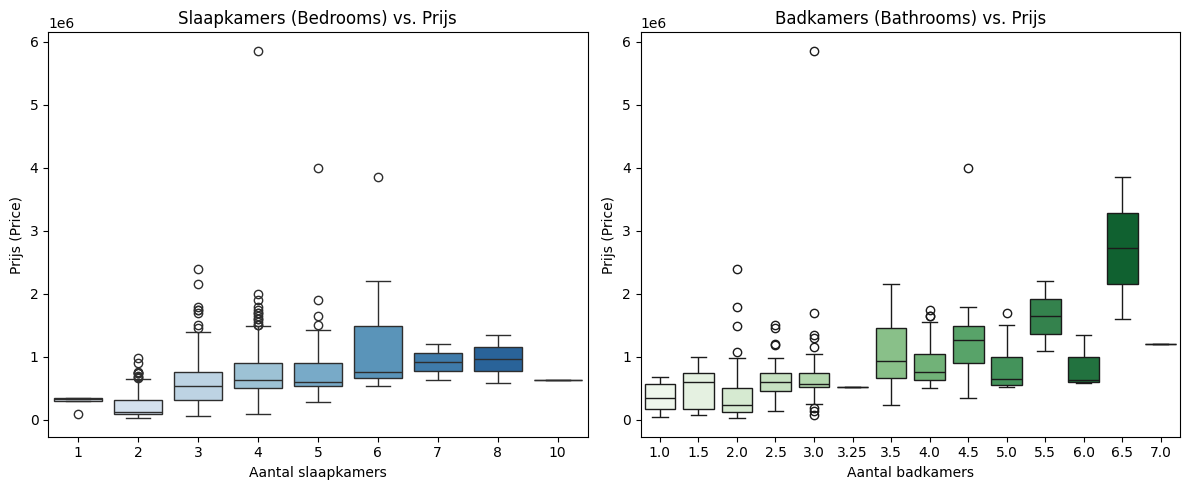

In [6]:
# Boxplots: Slaapkamers & Badkamers vs. Prijs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[0], palette="Blues")
axes[0].set_title("Slaapkamers (Bedrooms) vs. Prijs")
axes[0].set_xlabel("Aantal slaapkamers")
axes[0].set_ylabel("Prijs (Price)")

sns.boxplot(data=df, x="Bathrooms", y="Price", ax=axes[1], palette="Greens")
axes[1].set_title("Badkamers (Bathrooms) vs. Prijs")
axes[1].set_xlabel("Aantal badkamers")
axes[1].set_ylabel("Prijs (Price)")

plt.tight_layout()
plt.show()

### Bevindingen

**Relatie Slaapkamers en Prijs:** Er is een duidelijke stijgende lijn te zien in de gemiddelde prijs bij huizen van 2 tot en met 6 slaapkamers. Opvallend is dat bij huizen met nog meer slaapkamers 7 of meer de prijs juist weer afvlakt. Ook zien we heel veel uitschieters.

**Relatie Badkamers en Prijs:** Bij de badkamers is de stijgende trend over de hele linie eigenlijk nog iets sterker. Vooral vanaf 3,5 badkamers begint de prijs flink op te lopen. Ook hier is een uitschieter in de categorie met 3 badkamers.

**Conclusie:** Meer kamers betekent meestal een duurder huis, maar het aantal badkamers lijkt een net iets sterkere voorspeller voor huizen in het dure segment dan het aantal slaapkamers. De grote hoeveelheid uitschieters (rondjes boven de boxen) bevestigt opnieuw dat deze variabelen samen met de oppervlakte, locatie en foto's gecombineerd moeten worden voor een echt accuraat model.


- - -
### 1.6.3 Geografische spreiding van woningprijzen

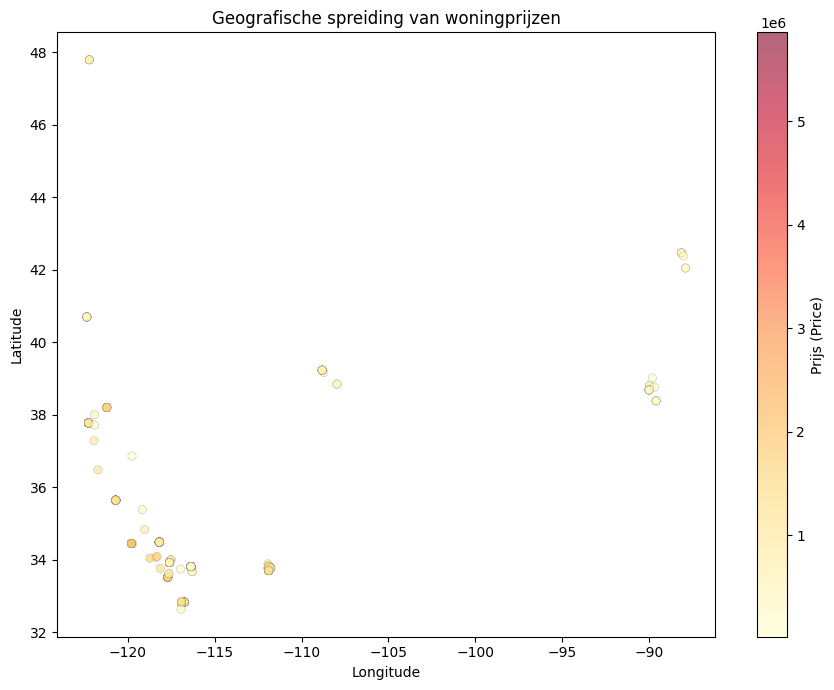

In [7]:
# Geografische scatterplot: Longitude vs. Latitude, gekleurd op Prijs
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Price"],
    cmap="YlOrRd",
    alpha=0.6,
    edgecolors="grey",
    linewidths=0.3,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Prijs (Price)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geografische spreiding van woningprijzen")
plt.tight_layout()
plt.show()

Geografische clusters: De huizen in onze dataset zijn niet gelijkmatig verspreid, maar liggen in heel duidelijke groepen. We zien een hele grote concentratie aan de linkerkant  en een paar kleinere plukjes verder naar het oosten. Er zit een enorm leeg gebied tussenin.

Prijs en locatie: De meeste stippen zijn lichtgeel, wat overeenkomt met de grote massa huizen onder de 1,5 miljoen dollar die we al eerder zagen. maar we zien  in de drukke clusters linksonder ook wat donkerdere oranje stippen opduiken.


- - -
### 1.6.4 Correlatie-heatmap

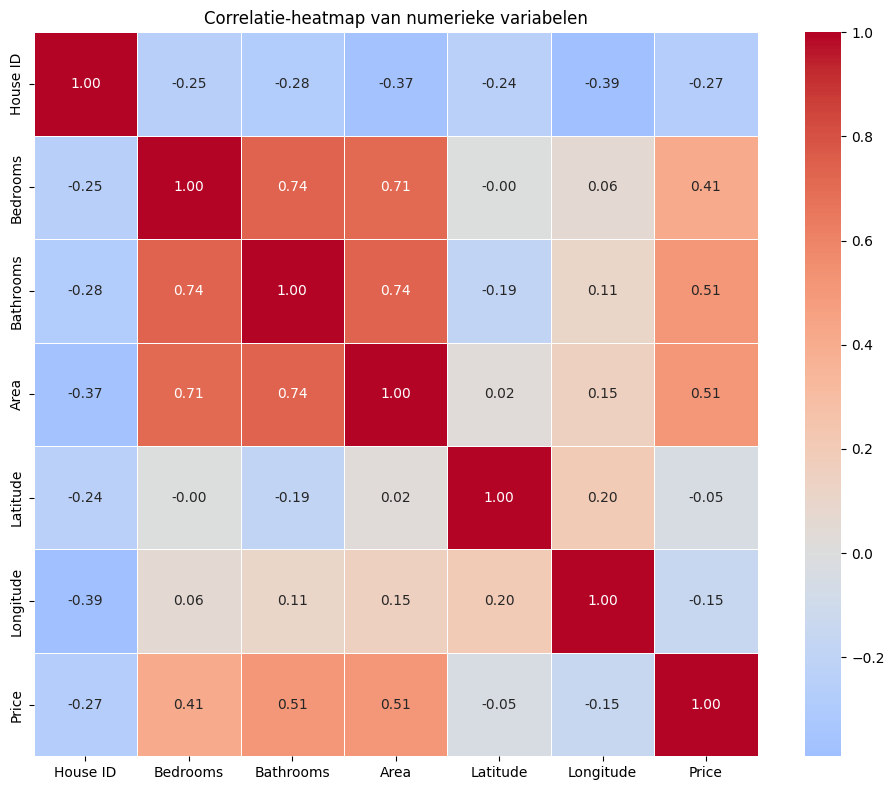

In [8]:
# Correlatie-heatmap van alle numerieke variabelen
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlatie-heatmap van numerieke variabelen")
plt.tight_layout()
plt.show()

Belangrijkste voorspellers: De oppervlakte  en het aantal badkamers  hebben de sterkste positieve correlatie met de verkoopprijs beide 0.51. Direct daarna volgt het aantal slaapkamers 0.41. Dit bevestigt dat de grootte en het aantal kamers belangrijke factoren zijn voor een hogere prijs.

Onderlinge samenhang: Er is een sterke samenhang te zien tussen de variabelen Area, Bathrooms en Bedrooms correlaties tussen de 0.71 en 0.74. 

Locatie: De lengte en breedtegraad  tonen vrijwel geen lineaire correlatie met de prijs -0.15 en -0.05. Dit betekent niet dat locatie onbelangrijk is, maar wel dat de relatie complexer is.

